In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgp_df_SR = pickle.load(open('sgp_set_cnn','rb')) 
print(sgp_df_SR.shape)
print('1s prop = ', sgp_df_SR.y_true.sum()/sgp_df_SR.shape[0])
sgp_df_SR.head() 

(40000, 3)
1s prop =  0.1012


,y_true,y_pred,kappa
0,0.0,0.0,0.968736
1,0.0,1.0,0.870544
2,0.0,0.0,0.882295
3,0.0,0.0,0.768718
4,0.0,1.0,0.739913


In [3]:
sgp_df_MCD = pickle.load(open('sgp_set_cnn_MCD','rb')) 
print(sgp_df_MCD.shape)
sgp_df_MCD.head() 

(40000, 3)


,y_true,y_pred,kappa
0,0.0,0.0,-0.000774
1,0.0,1.0,-0.004592
2,0.0,0.0,-0.004616
3,0.0,0.0,-0.004997
4,0.0,1.0,-0.005230


In [4]:
train_set_SR, test_set_SR = train_test_split(sgp_df_SR, seed=16) # drawing 3/4 for bounds fitting, 1/4 for bounds testing
train_set_MCD, test_set_MCD = train_test_split(sgp_df_MCD, seed=16)

In [5]:
delta = 0.005

In [6]:
color_map = {'standard': "#d51414",
             'FP': "#8F7A1C",
             'FN': "#0f770a",
             'FPR': "#403535",
             'FNR': "#1d3ae2",
             'SE': "#93139c",
             'SP': "#0F8592",
             'PPV': "#676767"}

### Joint evolution of metrics with respect to $\theta$ and coverage

standard  bounds


 96%|█████████▌| 48/50 [00:19<00:00,  2.50it/s]


FP  bounds


 96%|█████████▌| 48/50 [00:16<00:00,  2.90it/s]


FN  bounds


...

 86%|████████▌ | 43/50 [00:16<00:02,  2.62it/s]


SE  bounds


 86%|████████▌ | 43/50 [00:03<00:00, 12.70it/s]


SP  bounds


 96%|█████████▌| 48/50 [00:18<00:00,  2.54it/s]


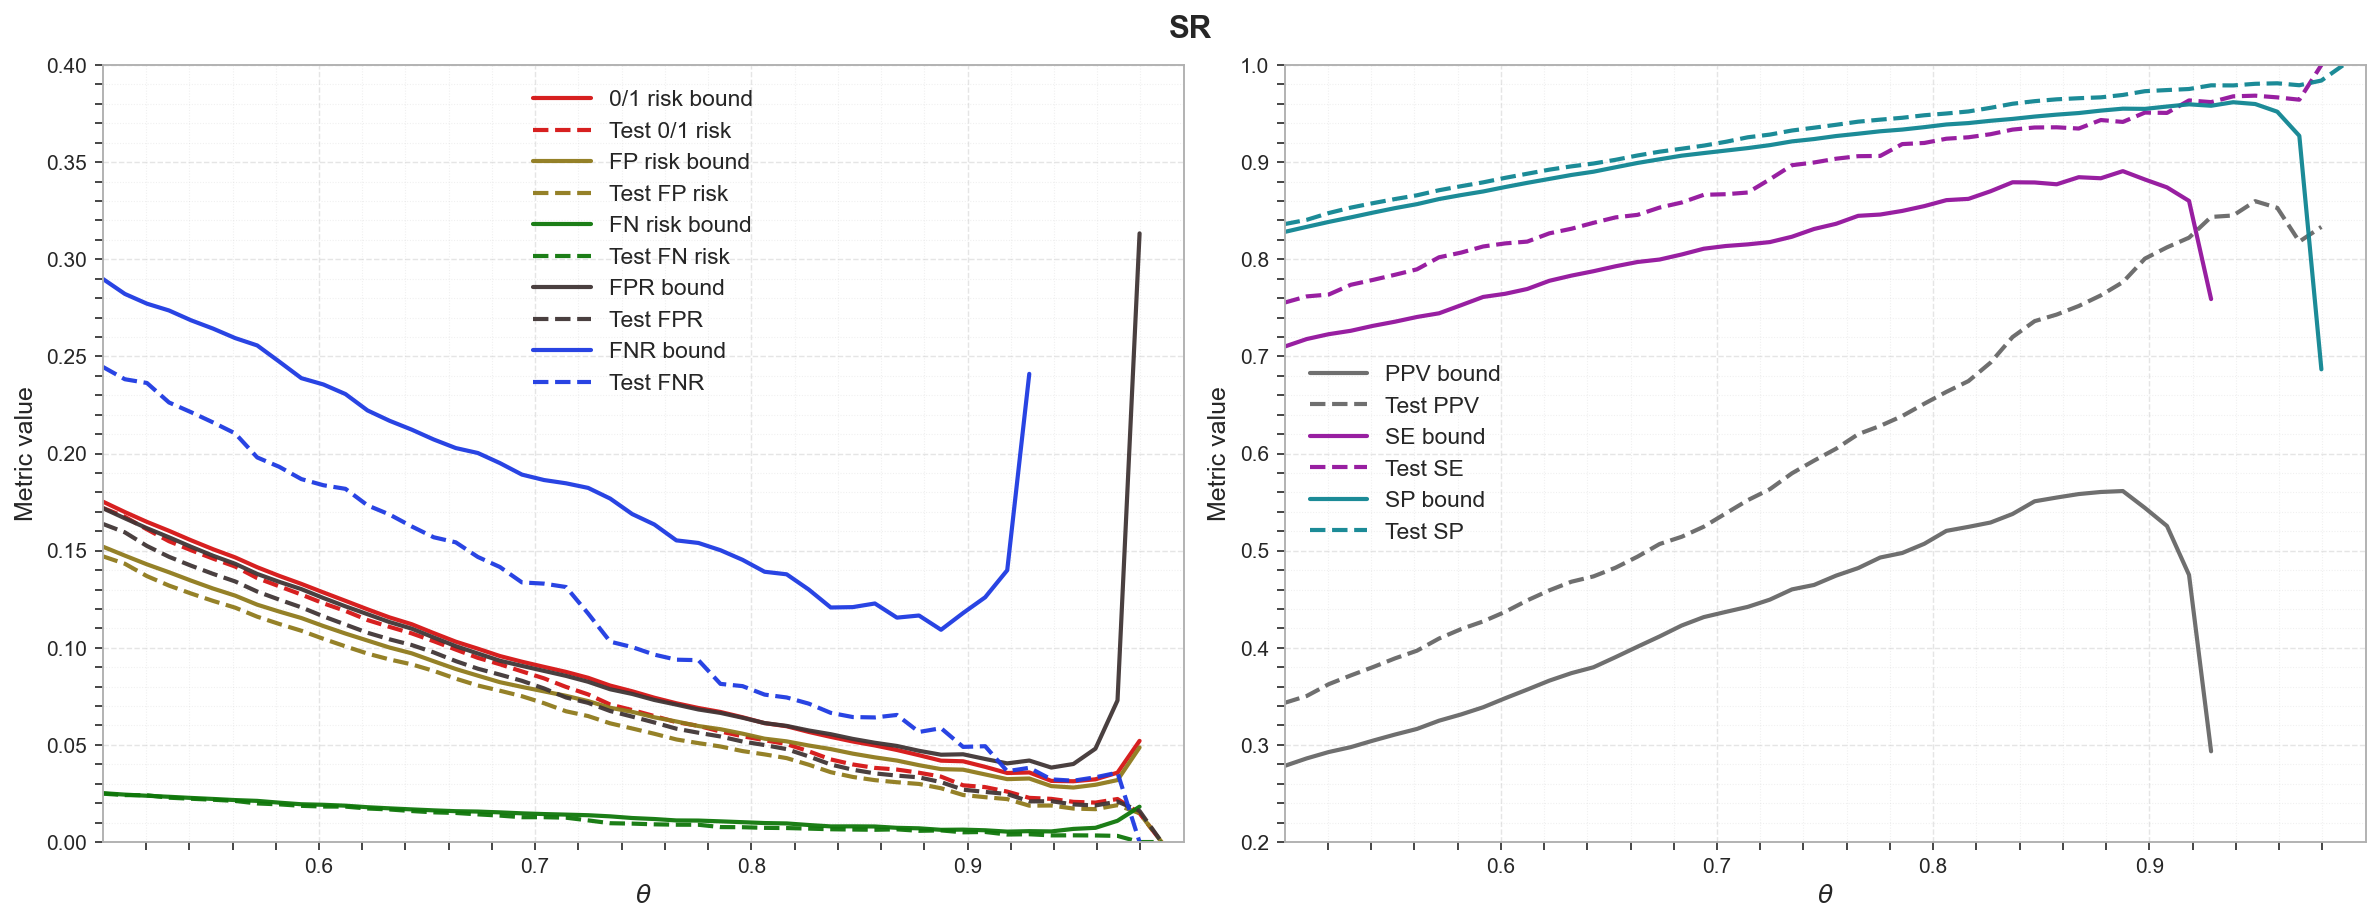

In [7]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 xlim1=[0.5,1], xlim2=[0.5,1],
                 ylim1=[0,0.4], ylim2=[0.2,1])

standard  bounds


  0%|          | 0/50 [00:00<?, ?it/s]

 96%|█████████▌| 48/50 [00:18<00:00,  2.59it/s]


FP  bounds


 96%|█████████▌| 48/50 [00:16<00:00,  2.90it/s]


...

 86%|████████▌ | 43/50 [00:14<00:02,  3.01it/s]


SE  bounds


 86%|████████▌ | 43/50 [00:02<00:00, 17.15it/s]


SP  bounds


 96%|█████████▌| 48/50 [00:14<00:00,  3.31it/s]


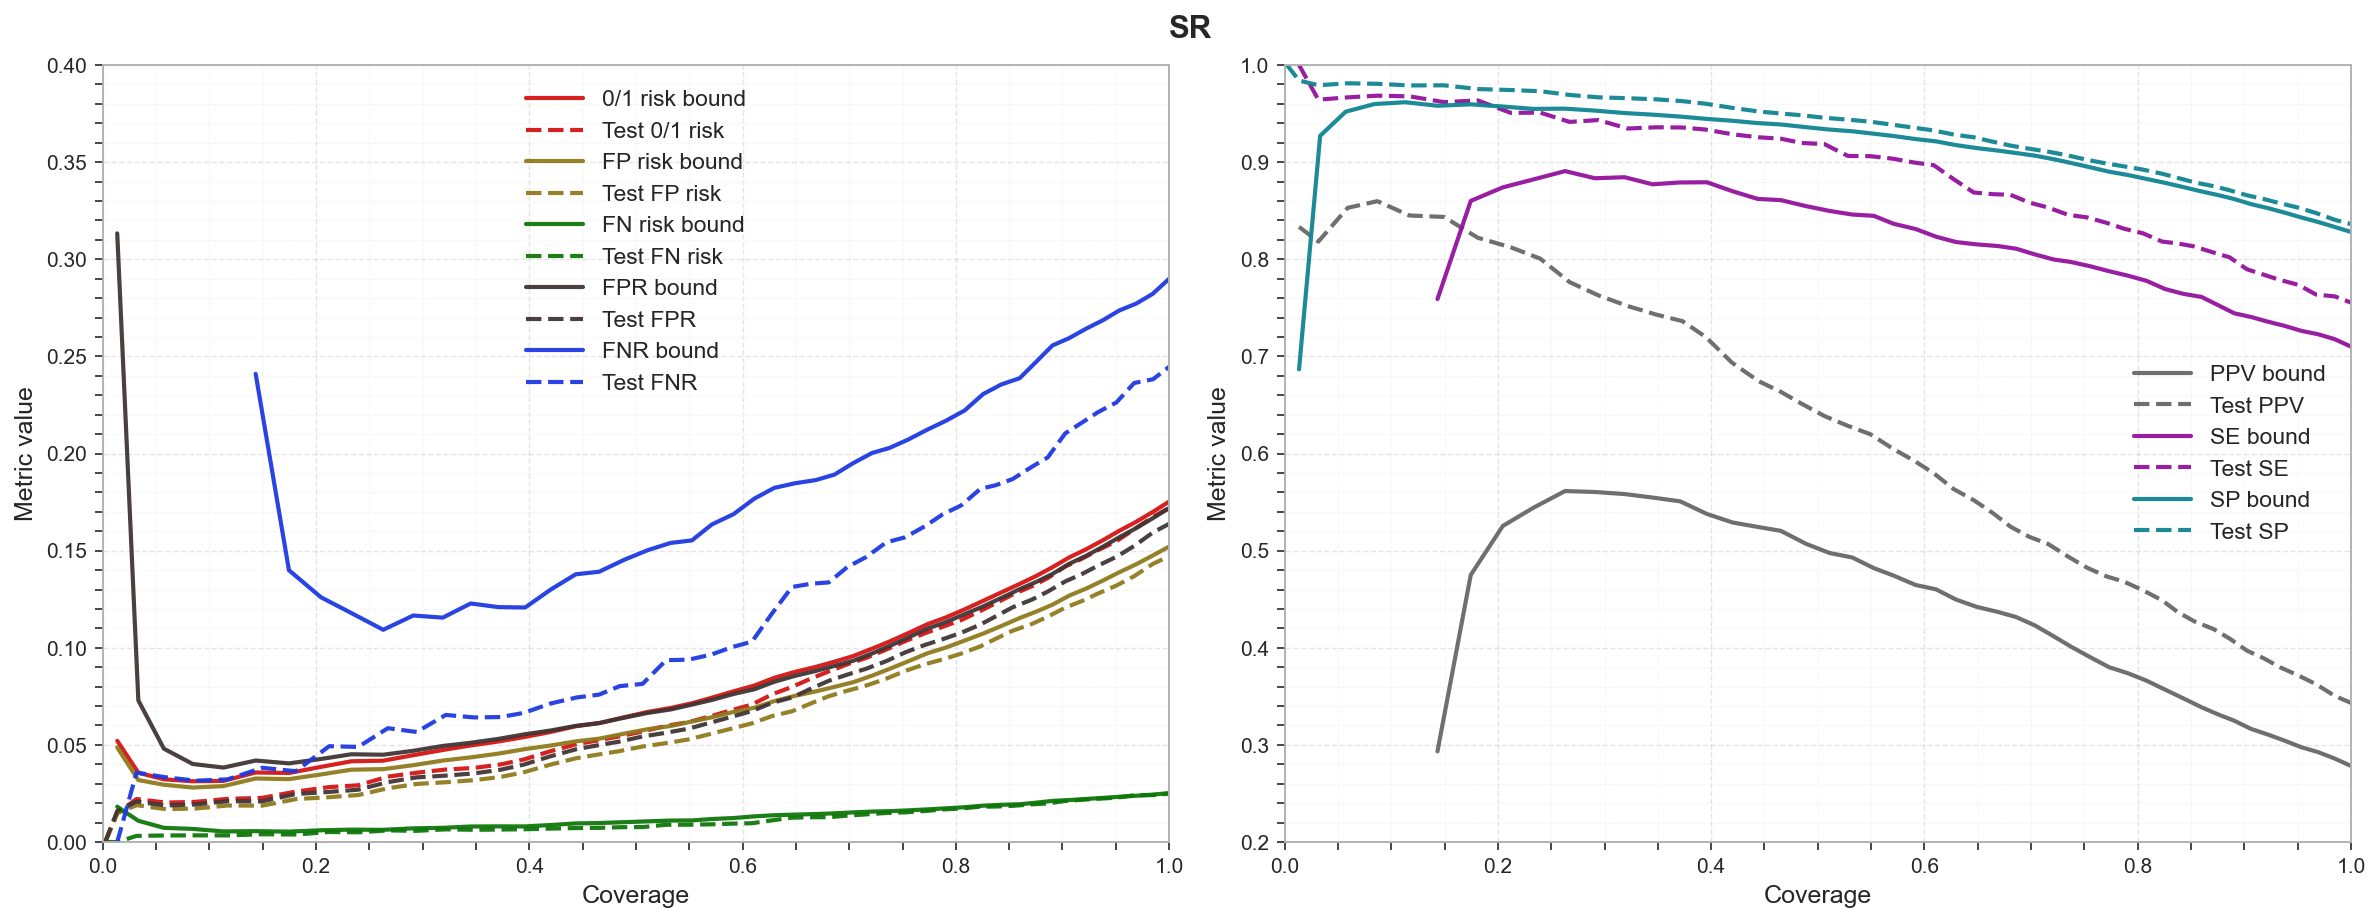

In [8]:
plot_all_metrics(train_set_SR, test_set_SR,
                 delta, color_map, title='SR',
                 ylim1=[0,0.4], ylim2=[0.2,1],
                 by_coverage=True)

standard  bounds


 98%|█████████▊| 49/50 [00:41<00:00,  1.19it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:33<00:00,  1.44it/s]


FN  bounds


...

 98%|█████████▊| 49/50 [00:34<00:00,  1.44it/s]


SE  bounds


 98%|█████████▊| 49/50 [00:05<00:00,  8.40it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:35<00:00,  1.39it/s]


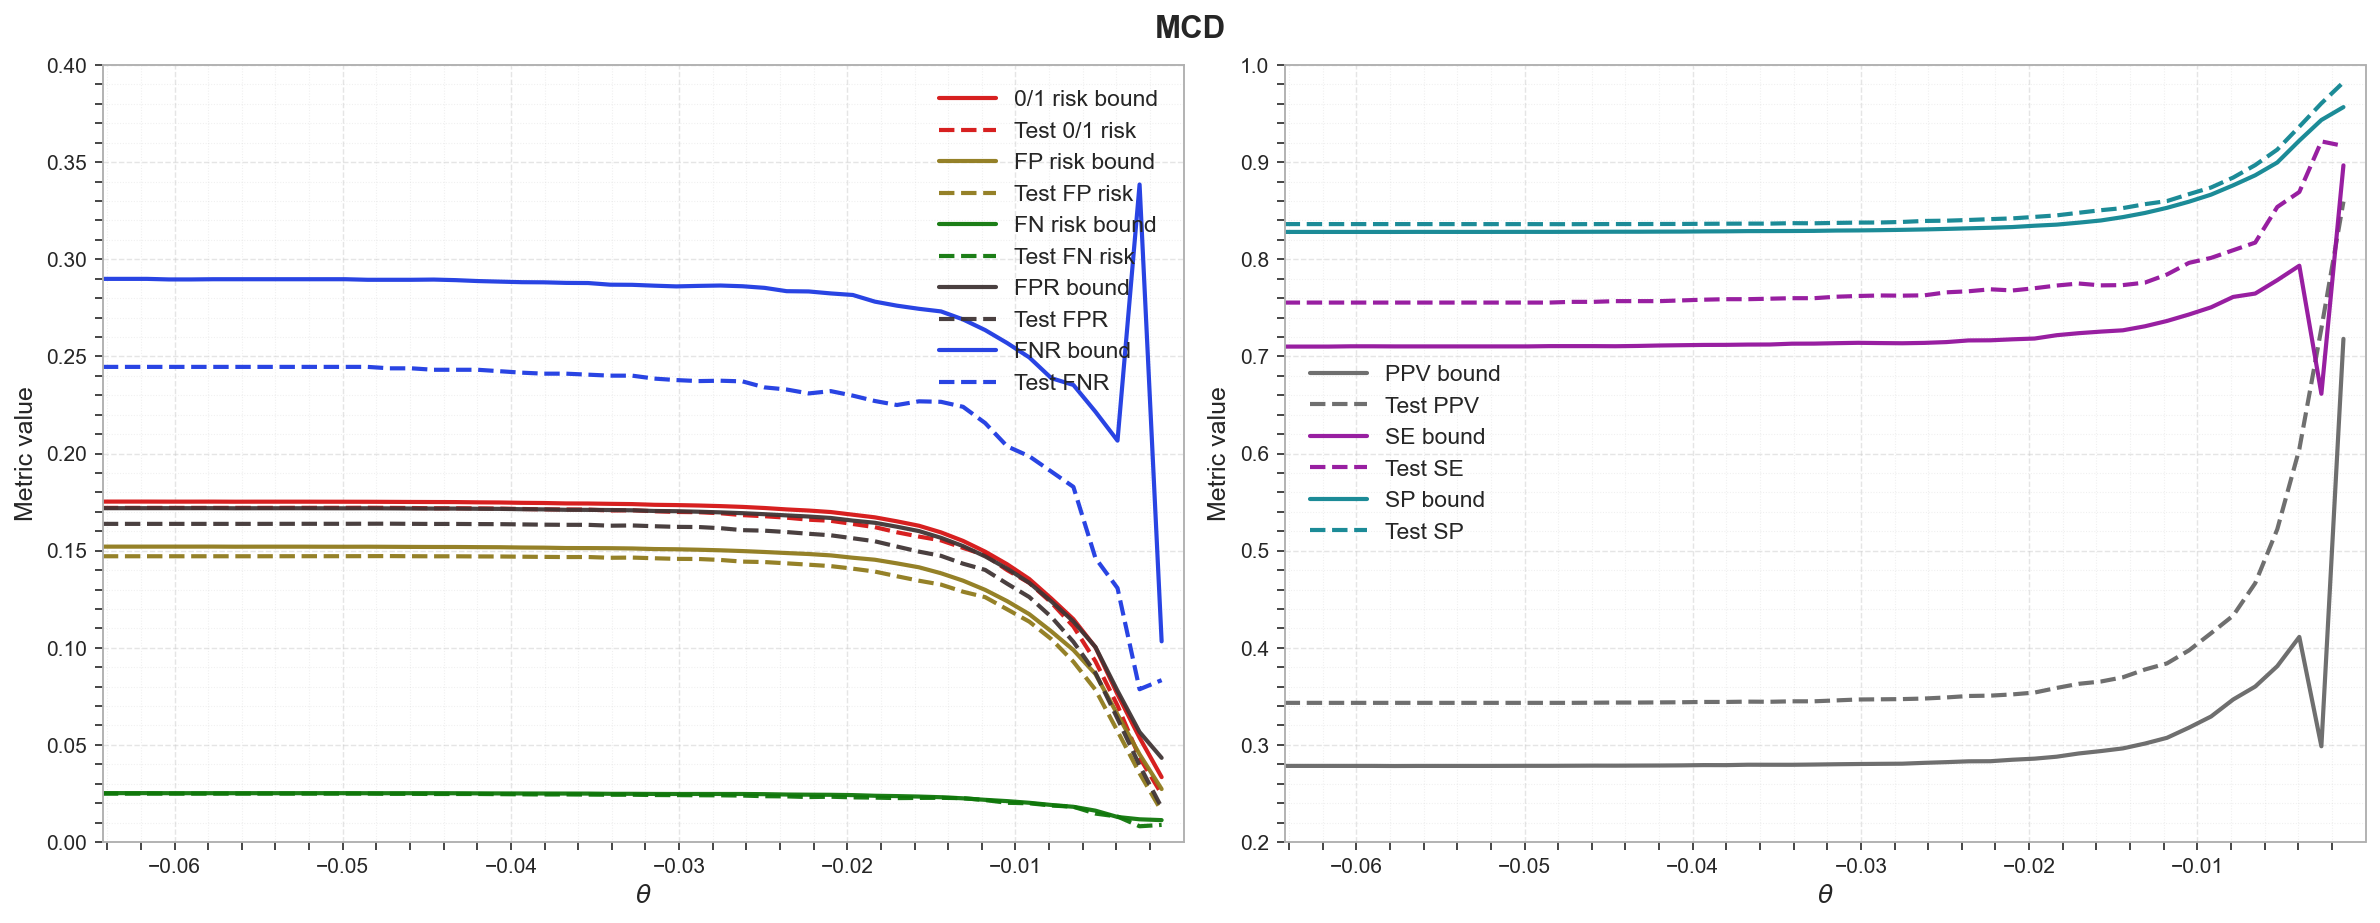

In [9]:
plot_all_metrics(train_set_MCD, test_set_MCD,
                 delta, color_map, title='MCD',
                 xlim1=[-0.07,0], xlim2=[-0.07,0],
                 ylim1=[0,0.4], ylim2=[0.2,1])

standard  bounds


  0%|          | 0/50 [00:00<?, ?it/s]

 98%|█████████▊| 49/50 [00:40<00:00,  1.22it/s]


FP  bounds


 98%|█████████▊| 49/50 [00:34<00:00,  1.41it/s]


...

 98%|█████████▊| 49/50 [00:34<00:00,  1.43it/s]


SE  bounds


 98%|█████████▊| 49/50 [00:06<00:00,  8.06it/s]


SP  bounds


 98%|█████████▊| 49/50 [00:33<00:00,  1.45it/s]


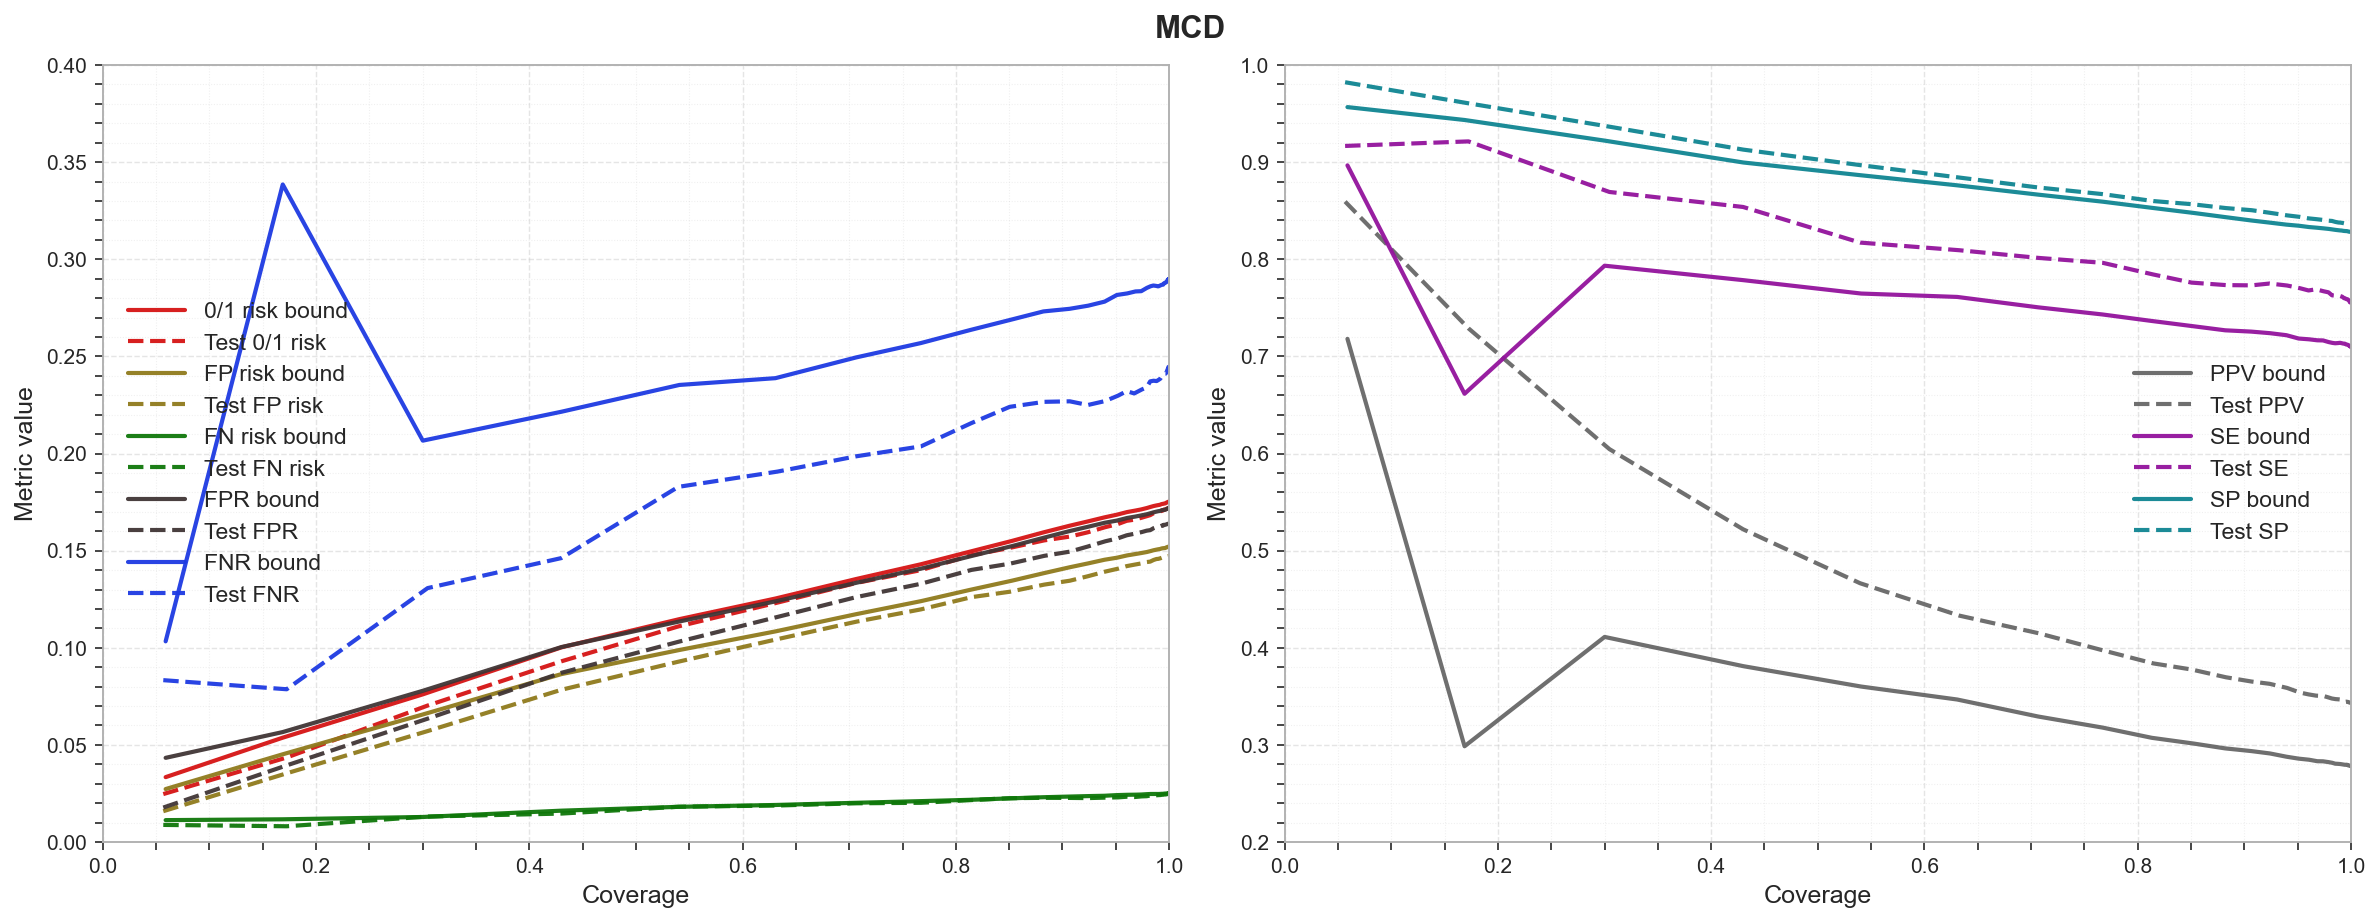

In [10]:
plot_all_metrics(train_set_MCD, test_set_MCD,
                 delta, color_map, title='MCD',
                 ylim1=[0,0.4], ylim2=[0.2,1],
                 by_coverage=True)

### Find best $\theta$ in the intersection of metrics $\theta$ regions, if non empty

In [11]:
metrics_and_targets = {'FNR' : 0.2,
                       'FPR' : 0.1}

In [12]:
joint_output = joint_control(metrics_and_targets, train_set_SR, delta, plot=False)
joint_output

FNR  bounds


 87%|████████▋ | 87/100 [00:04<00:00, 18.33it/s]


FPR  bounds


 97%|█████████▋| 97/100 [00:27<00:00,  3.52it/s]


{'theta_intervals': [(np.float64(0.671714904934469),
   np.float64(0.9242281462206985))],
 'best_theta': np.float64(0.671714904934469)}

### All reachable bounds for a couple of 2 metrics

In [13]:
metrics = ['standard', 'FP', 'FN', 'FPR',
           'FNR','PPV', 'SE','SP']

all_bounds_SR = reachable_bounds(metrics, train_set_SR, delta, steps=100)
all_bounds_MCD = reachable_bounds(metrics, train_set_MCD, delta, steps=100)

standard  bounds


 97%|█████████▋| 97/100 [00:31<00:00,  3.06it/s]


FP  bounds


 97%|█████████▋| 97/100 [00:27<00:00,  3.50it/s]


FN  bounds


...

 96%|█████████▌| 96/100 [01:06<00:02,  1.45it/s]


SE  bounds


 96%|█████████▌| 96/100 [00:11<00:00,  8.32it/s]


SP  bounds


 99%|█████████▉| 99/100 [01:05<00:00,  1.52it/s]


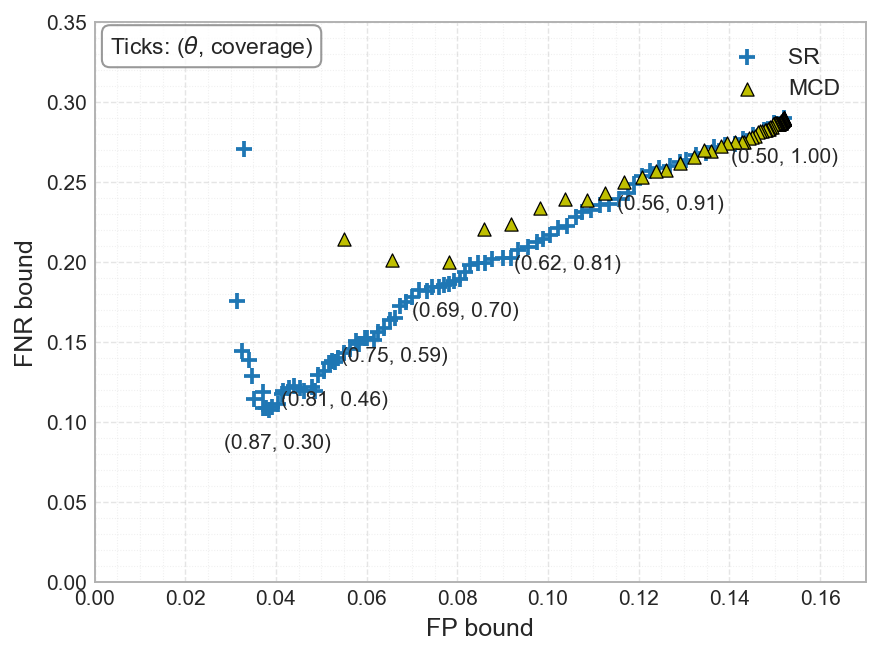

In [14]:
metric1 = 'FP'
metric2 = 'FNR'

two_metrics_bounds(metric1, metric2, all_bounds_SR, all_bounds_MCD=all_bounds_MCD,num_labels=9,xlim=[0,0.17], ylim=[0,0.35])